# Experiment 4.0 — Fixed250 temporal SNN decoder

## Scientific question

Can a stateful SNN replace a flattened Linear classifier after the raw 30-channel weighted event train has already been compressed into ordered 250 ms channel-wise sums?

All methods consume the same representation:

$$X_{1:T}\rightarrow z_1,\ldots,z_B,\qquad z_{b,c}=\sum_{t\in W_b,\ t<L}X_{t,c}.$$

A train-only per-channel scale is fitted on valid bins and applied without mean subtraction, so padded zero bins remain exactly zero.

The SNN always executes the complete padded macro sequence. Valid length changes only the readout window, not state evolution. Primary training uses valid WholeCount CE; full WholeCount and valid/full final membrane are diagnostic readouts from the same trajectory.

## Experiment matrix

- Decoder: `ff`, `rsnn`
- Hidden width: 32, 64, 128
- Hidden $\tau_{mem}$: 250, 500, 1000, 2000 ms
- Seeds: 11, 23, 37, 53, 71
- 120 independent SNN runs + one shared Fixed250+Linear baseline

For hidden width $H$, recurrence adds $H^2$ trainable parameters because $W_{rec}\in\mathbb{R}^{H\times H}$.

## Result availability

This notebook is intentionally **analysis-only**. It can be opened before the Slurm sweep has finished. The setup cell below reports whether the 120 SNN evaluation artifacts, Linear baseline, and finalized CSV files are present. Plot cells are skipped until `runs.csv` and `summary.csv` exist.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from scripts import experiment_4_0_fixed250_temporal_snn as exp40

root = exp40.results_dir(repo_root)
runs_path = root / 'runs.csv'
summary_path = root / 'summary.csv'
baseline_path = root / 'baseline' / 'fixed250_linear.json'
evaluation_dir = root / 'evaluations'
evaluation_count = len(list(evaluation_dir.glob('*.json'))) if evaluation_dir.exists() else 0
expected_runs = len(exp40.run_specs())
results_ready = runs_path.exists() and summary_path.exists() and baseline_path.exists()

print('Artifact root:', root)
print(f'SNN evaluation artifacts: {evaluation_count}/{expected_runs}')
print('Linear baseline:', 'present' if baseline_path.exists() else 'missing')
print('Finalized runs.csv:', 'present' if runs_path.exists() else 'missing')
print('Finalized summary.csv:', 'present' if summary_path.exists() else 'missing')

if results_ready:
    runs = pd.read_csv(runs_path)
    summary = pd.read_csv(summary_path)
    baseline = json.loads(baseline_path.read_text())
    display(summary)
    print('Linear test BA:', baseline['metrics']['test']['balanced_accuracy'])
else:
    runs = None
    summary = None
    baseline = None
    if evaluation_count == expected_runs and baseline_path.exists():
        print('\nAll run artifacts are present but final CSVs are missing.')
        print('Submit the finalizer with:')
        print('  sbatch scripts/bash_script/SNN_Bash/finalize_exp_4_0_cpu.bash')
    else:
        print('\nFinalized results are not available yet.')
        print('The finalizer creates runs.csv and summary.csv only after all required run artifacts exist.')

Artifact root: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_4_0_fixed250_temporal_snn/fixed250_stateful_decoder_v1
SNN evaluation artifacts: 120/120
Linear baseline: present
Finalized runs.csv: present
Finalized summary.csv: present


,architecture,hidden_width,tau_mem_ms,tail_spike_fraction_mean,tail_spike_fraction_std,valid_count_balanced_accuracy_mean,valid_count_balanced_accuracy_std,valid_count_macro_f1_mean,valid_count_macro_f1_std,full_count_balanced_accuracy_mean,...,full_count_macro_f1_mean,full_count_macro_f1_std,valid_membrane_balanced_accuracy_mean,valid_membrane_balanced_accuracy_std,valid_membrane_macro_f1_mean,valid_membrane_macro_f1_std,full_membrane_balanced_accuracy_mean,full_membrane_balanced_accuracy_std,full_membrane_macro_f1_mean,full_membrane_macro_f1_std
0,ff,32,250.0,0.000000,0.000000,0.206892,0.032674,0.170466,0.029407,0.206892,...,0.170466,0.029407,0.107783,0.022158,0.100798,0.022806,0.077260,0.022056,0.073054,0.020467
1,ff,32,500.0,0.005060,0.003113,0.198048,0.033553,0.172598,0.037243,0.199238,...,0.172758,0.039229,0.123027,0.017776,0.110183,0.017148,0.090216,0.024586,0.088118,0.026471
2,ff,32,1000.0,0.042488,0.025425,0.217082,0.032949,0.186131,0.027858,0.221753,...,0.193547,0.023677,0.150747,0.031848,0.134368,0.029137,0.096079,0.024737,0.082463,0.030805
3,ff,32,2000.0,0.072708,0.013197,0.225809,0.016325,0.196010,0.021463,0.233703,...,0.197779,0.016516,0.151660,0.023455,0.133172,0.029964,0.092755,0.017248,0.057656,0.032424
4,ff,64,250.0,0.000000,0.000000,0.225579,0.017644,0.193463,0.020132,0.225579,...,0.193463,0.020132,0.119534,0.037244,0.113168,0.035896,0.099825,0.030902,0.096677,0.032359
5,ff,64,500.0,0.004129,0.001688,0.235561,0.033188,0.205525,0.030607,0.234046,...,0.202787,0.027262,0.106019,0.024068,0.091633,0.023423,0.086919,0.014915,0.077777,0.015545
6,ff,64,1000.0,0.052189,0.025089,0.256017,0.030015,0.230693,0.028807,0.260833,...,0.231851,0.013637,0.166771,0.031770,0.155088,0.032312,0.071882,0.041853,0.040812,0.047234
7,ff,64,2000.0,0.109219,0.027494,0.276308,0.037285,0.255116,0.039109,0.279051,...,0.252505,0.055919,0.144543,0.013845,0.128170,0.014917,0.062231,0.017996,0.029440,0.010608
8,ff,128,250.0,0.000000,0.000000,0.247563,0.033449,0.218625,0.025802,0.247563,...,0.218625,0.025802,0.121605,0.029889,0.115011,0.029083,0.100199,0.029901,0.096255,0.029144
9,ff,128,500.0,0.006121,0.002819,0.254772,0.040497,0.226692,0.039634,0.258668,...,0.230198,0.041620,0.123983,0.037118,0.114703,0.039696,0.105063,0.032156,0.090479,0.034204


Linear test BA: 0.5491064491064491


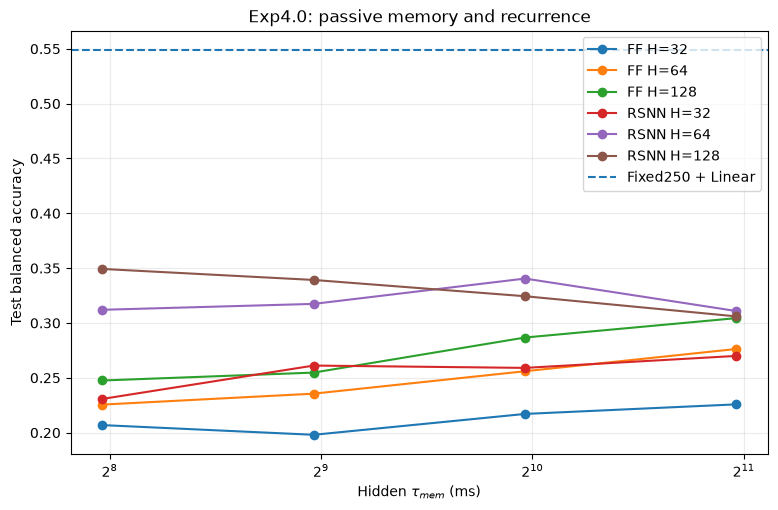

In [2]:
if not results_ready:
    print('Skipped: memory/recurrence plot requires finalized runs.csv.')
else:
    test = runs[runs['split'] == 'test'].copy()
    mean_ba = (
        test.groupby(['architecture', 'hidden_width', 'tau_mem_ms'], as_index=False)
            ['valid_count_balanced_accuracy'].mean()
    )
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for (architecture, width), frame in mean_ba.groupby(['architecture', 'hidden_width']):
        frame = frame.sort_values('tau_mem_ms')
        ax.plot(frame['tau_mem_ms'], frame['valid_count_balanced_accuracy'], marker='o', label=f'{architecture.upper()} H={width}')
    ax.axhline(baseline['metrics']['test']['balanced_accuracy'], linestyle='--', label='Fixed250 + Linear')
    ax.set_xscale('log', base=2)
    ax.set_xlabel(r'Hidden $\tau_{mem}$ (ms)')
    ax.set_ylabel('Test balanced accuracy')
    ax.set_title('Exp4.0: passive memory and recurrence')
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.show()

,architecture,hidden_width,tau_mem_ms,seed,valid_count_balanced_accuracy,full_count_balanced_accuracy,tail_spike_fraction
104,rsnn,128,250.0,71,0.392172,0.282648,0.708861
113,rsnn,128,1000.0,53,0.386661,0.235415,0.571921
93,rsnn,64,1000.0,53,0.382595,0.215152,0.586168
101,rsnn,128,250.0,23,0.375653,0.289985,0.511394
109,rsnn,128,500.0,71,0.373644,0.278608,0.623132
103,rsnn,128,250.0,53,0.368659,0.305051,0.671446
107,rsnn,128,500.0,37,0.361903,0.213005,0.712559
97,rsnn,64,2000.0,37,0.357054,0.203481,0.587011
82,rsnn,64,250.0,37,0.352084,0.330162,0.199298
89,rsnn,64,500.0,71,0.349618,0.276696,0.493797


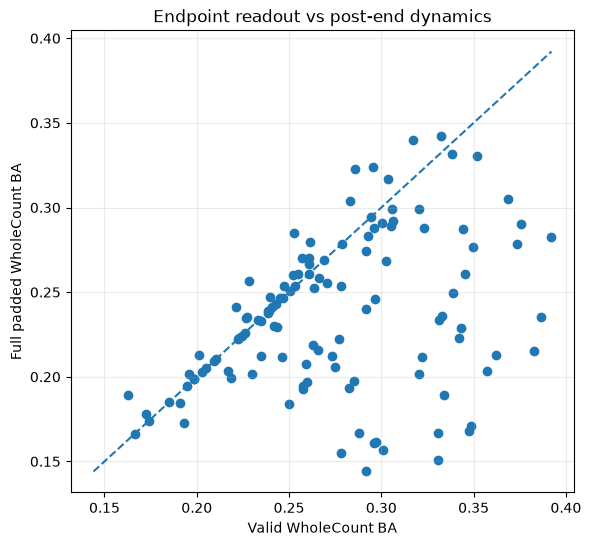

In [3]:
if not results_ready:
    print('Skipped: endpoint-vs-full readout analysis requires finalized runs.csv.')
else:
    test = runs[runs['split'] == 'test'].copy()
    paired = (
        test.groupby(['architecture', 'hidden_width', 'tau_mem_ms', 'seed'], as_index=False)
            [['valid_count_balanced_accuracy', 'full_count_balanced_accuracy', 'tail_spike_fraction']].first()
    )
    display(paired.sort_values('valid_count_balanced_accuracy', ascending=False).head(20))

    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    ax.scatter(paired['valid_count_balanced_accuracy'], paired['full_count_balanced_accuracy'])
    lo = min(paired['valid_count_balanced_accuracy'].min(), paired['full_count_balanced_accuracy'].min())
    hi = max(paired['valid_count_balanced_accuracy'].max(), paired['full_count_balanced_accuracy'].max())
    ax.plot([lo, hi], [lo, hi], linestyle='--')
    ax.set_xlabel('Valid WholeCount BA')
    ax.set_ylabel('Full padded WholeCount BA')
    ax.set_title('Endpoint readout vs post-end dynamics')
    ax.grid(True, alpha=0.25)
    plt.show()

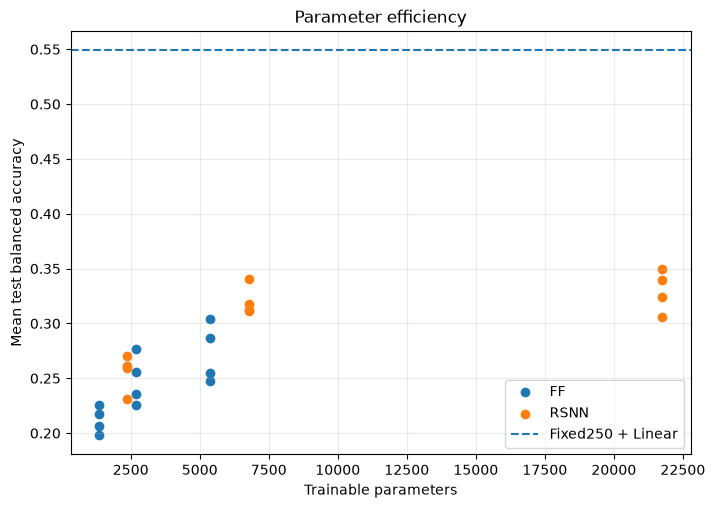

In [4]:
if not results_ready:
    print('Skipped: parameter-efficiency plot requires finalized runs.csv.')
else:
    test = runs[runs['split'] == 'test'].copy()
    param_view = (
        test.groupby(['architecture', 'hidden_width', 'tau_mem_ms', 'parameter_count'], as_index=False)
            ['valid_count_balanced_accuracy'].mean()
    )
    fig, ax = plt.subplots(figsize=(8, 5.5))
    for architecture, frame in param_view.groupby('architecture'):
        ax.scatter(frame['parameter_count'], frame['valid_count_balanced_accuracy'], label=architecture.upper())
    ax.axhline(baseline['metrics']['test']['balanced_accuracy'], linestyle='--', label='Fixed250 + Linear')
    ax.set_xlabel('Trainable parameters')
    ax.set_ylabel('Mean test balanced accuracy')
    ax.set_title('Parameter efficiency')
    ax.legend()
    ax.grid(True, alpha=0.25)
    plt.show()